# Scalar waves

## Wave packets

This figure shows a simple harmonic wave and the wave group formed by two nearby waves. The upper panel contains the carrier wave, while the lower panel contains the wave group and its positive and negative envelopes.

For two nearby waves, the wave group can be written schematically as

$$
V_{\mathrm{group}}(z,t) = 2a\cos\left[\frac{1}{2}(\Delta\omega\,t-\Delta k\,z)\right]\cos(\bar\omega t-\bar k z).
$$


### Parameters and wave functions

The following code defines the spatial grid and evaluates the carrier, envelope, and wave group at a chosen time.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


a = 1.0

omega_bar = 8.0       # central angular frequency
k_bar = 8.0           # central wave number

delta_omega = 0.8     # frequency difference
delta_k = 0.8         # wave-number difference

# Use x as a generic coordinate: t (or z).
x = np.linspace(0, 8 * np.pi, 2500)


def calculate_waves(x):
    """Calculate the carrier, envelope, and wave group along x."""

    phase = omega_bar * x
    envelope_phase = 0.5 * delta_omega * x

    carrier = a * np.cos(phase)
    envelope = 2 * a * np.cos(envelope_phase)
    wave_group = envelope * np.cos(phase)

    return carrier, envelope, wave_group


### Initial state

The static figure below is the PNG output embedded in the article. It contains no Plotly or animation data.


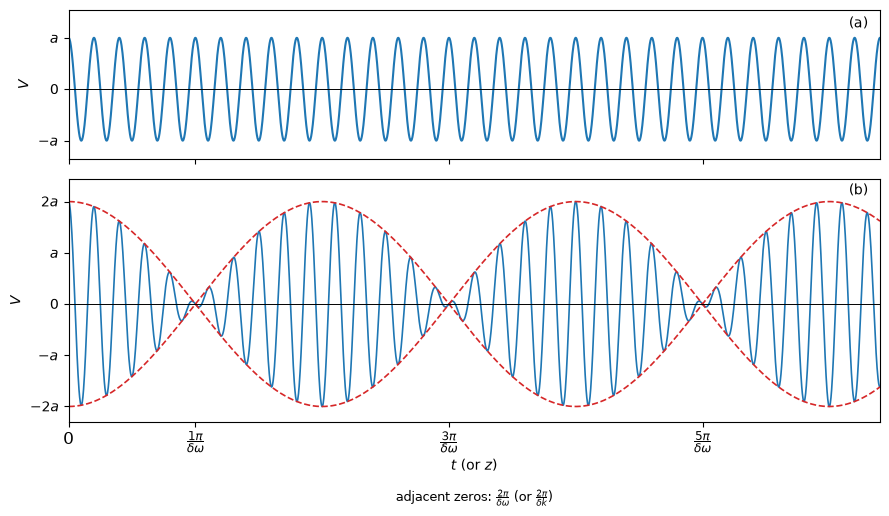

In [2]:
#| label: fig-wave-group
#| fig-cap: "A simple harmonic wave and a wave group formed by two nearby waves."
#| fig-width: 9
#| fig-height: 5.6

carrier, envelope, wave_group = calculate_waves(x)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 5.6),
    sharex=True,
    gridspec_kw={"height_ratios": [0.38, 0.62]},
)

# (a) Simple harmonic wave
axes[0].plot(x, carrier, color="#1f77b4", linewidth=1.5)
axes[0].set_ylabel(r"$V$")
axes[0].set_ylim(-1.35, 1.55)
axes[0].set_yticks([-a, 0, a])
axes[0].set_yticklabels([r"$-a$", r"$0$", r"$a$"])
axes[0].axhline(0, color="black", linewidth=0.7)
axes[0].text(0.985, 0.88, "(a)", transform=axes[0].transAxes, ha="right")

# (b) Wave group and envelopes
axes[1].plot(x, wave_group, color="#1f77b4", linewidth=1.2)
axes[1].plot(x, envelope, color="#d62728", linestyle="--", linewidth=1.2)
axes[1].plot(x, -envelope, color="#d62728", linestyle="--", linewidth=1.2)
axes[1].set_xlabel(r"$t$ (or $z$)")
axes[1].set_ylabel(r"$V$")
axes[1].set_ylim(-2.3, 2.45)
axes[1].set_yticks([-2 * a, -a, 0, a, 2 * a])
axes[1].set_yticklabels([r"$-2a$", r"$-a$", r"$0$", r"$a$", r"$2a$"])
axes[1].axhline(0, color="black", linewidth=0.7)
axes[1].text(0.985, 0.98, "(b)", transform=axes[1].transAxes, ha="right", va="top")

for axis in axes:
    axis.set_xlim(x.min(), x.max())
    axis.grid(False)

# Put x-axis ticks at the envelope zeros.
envelope_zero_positions = (2 * np.arange(10) + 1) * np.pi / delta_omega
envelope_zero_positions = envelope_zero_positions[
    envelope_zero_positions <= x.max()
]

x_ticks = np.concatenate(([0], envelope_zero_positions))
x_labels = [r"$0$"] + [
    rf"$\frac{{{2 * i + 1}\pi}}{{\delta\omega}}$"
    for i in range(len(envelope_zero_positions))
]
axes[1].set_xticks(x_ticks)
axes[1].set_xticklabels(x_labels)
for tick in axes[1].get_xticklabels():
    tick.set_fontsize(12)
    tick.set_fontweight("bold")

# The distance between adjacent envelope zeros is 2*pi/delta_omega.
axes[1].text(
    0.5,
    -0.28,
    r"adjacent zeros: $\frac{2\pi}{\delta\omega}$ (or $\frac{2\pi}{\delta k}$)",
    transform=axes[1].transAxes,
    ha="center",
    va="top",
    fontsize=9,
)

fig.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()
